# Genereren van een bewegingswet

In [3]:
# utility functions

from matplotlib import pyplot as plt
import numpy as np

dtheta      = 0.5 # angular resolution in degrees
range_theta = 360 # one full turn
theta_deg   = np.arange(0, range_theta, dtheta) 

lift    = np.zeros_like(theta_deg)
vel_deg = np.zeros_like(theta_deg)
acc_deg = np.zeros_like(theta_deg)
vel     = np.zeros_like(theta_deg)
acc     = np.zeros_like(theta_deg)

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlabel('Theta [deg]')
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Velocity [mm]/s")
    ax1[1].set_xlabel('Theta [deg]')
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acceleration [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


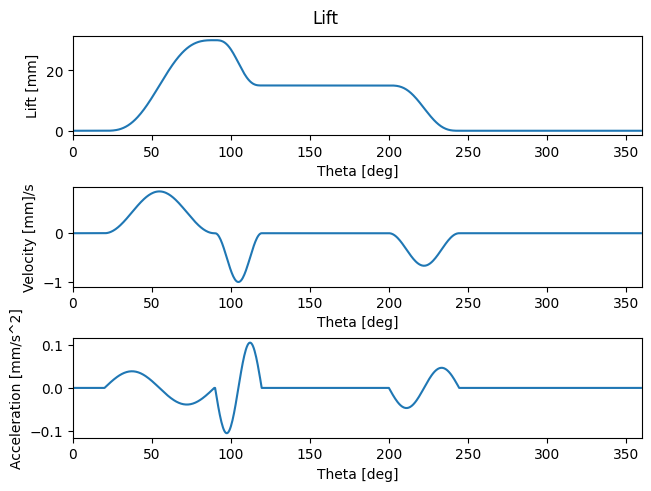

In [4]:
# Define motion segments

#Segment 1
startangle = 20 # degrees
endangle   = 90 # degrees
startlift  =  0 # mm
endlift    = 30 # mm
motionlaw  = 4  # discrete index

# Add the segment to the motion law
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta)

#Segment 2
startangle = 90
endangle = 120
startlift = 30
endlift = 15
motionlaw = 4

# Add the segment to the motion law
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta)

#Segment 3
startangle = 120
endangle = 200
startlift = 15
endlift = 15
motionlaw = 1

# Add the segment to the motion law
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta)

#Segment 4
startangle = 200
endangle = 245
startlift = 15
endlift = 0
motionlaw = 4

# Add the segment to the motion law
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta)

# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()